In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [6]:
path = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\Payment_Adonc\Payment\Contacts_Payment\Contacts.csv"
df=pd.read_csv(path)

In [7]:
#print(df.head(10))
#print(df.dtypes)
df= df[df['session_dt']!= "session_dt"]
df['session_dt'] = df['session_dt'].astype("datetime64[ns]")
print(df.dtypes)

year1                           int64
month1                          int64
wk1                             int64
session_dt             datetime64[ns]
marketplace_id                 object
is_shopsy_order                object
LOB                            object
issue_type                     object
sub_issue_type                 object
sub_sub_issue_type             object
ssi                            object
merchant_id                    object
live_response_code             object
transaction_status             object
merchant_status                object
pg_id                          object
transaction_source             object
payment_instrument             object
FRM_OCR_Flag                   object
flipkart_emi_flag              object
marketplace_context            object
Minutes_flag                   object
emi_flag                       object
contacts                        int64
inc_cnt                         int64
odr_cnt                         int64
acct_cnt    

In [8]:
#print(df.describe())
#print(df.isna())
print(df.isna().sum())

year1                       0
month1                      0
wk1                         0
session_dt                  0
marketplace_id         112716
is_shopsy_order        112716
LOB                      9321
issue_type                  0
sub_issue_type          15820
sub_sub_issue_type      90957
ssi                         0
merchant_id             40893
live_response_code      96468
transaction_status      40893
merchant_status         40893
pg_id                   41855
transaction_source      40894
payment_instrument      40893
FRM_OCR_Flag             9321
flipkart_emi_flag       40893
marketplace_context     48952
Minutes_flag                0
emi_flag               758067
contacts                    0
inc_cnt                     0
odr_cnt                     0
acct_cnt                    0
dtype: int64


<Axes: >

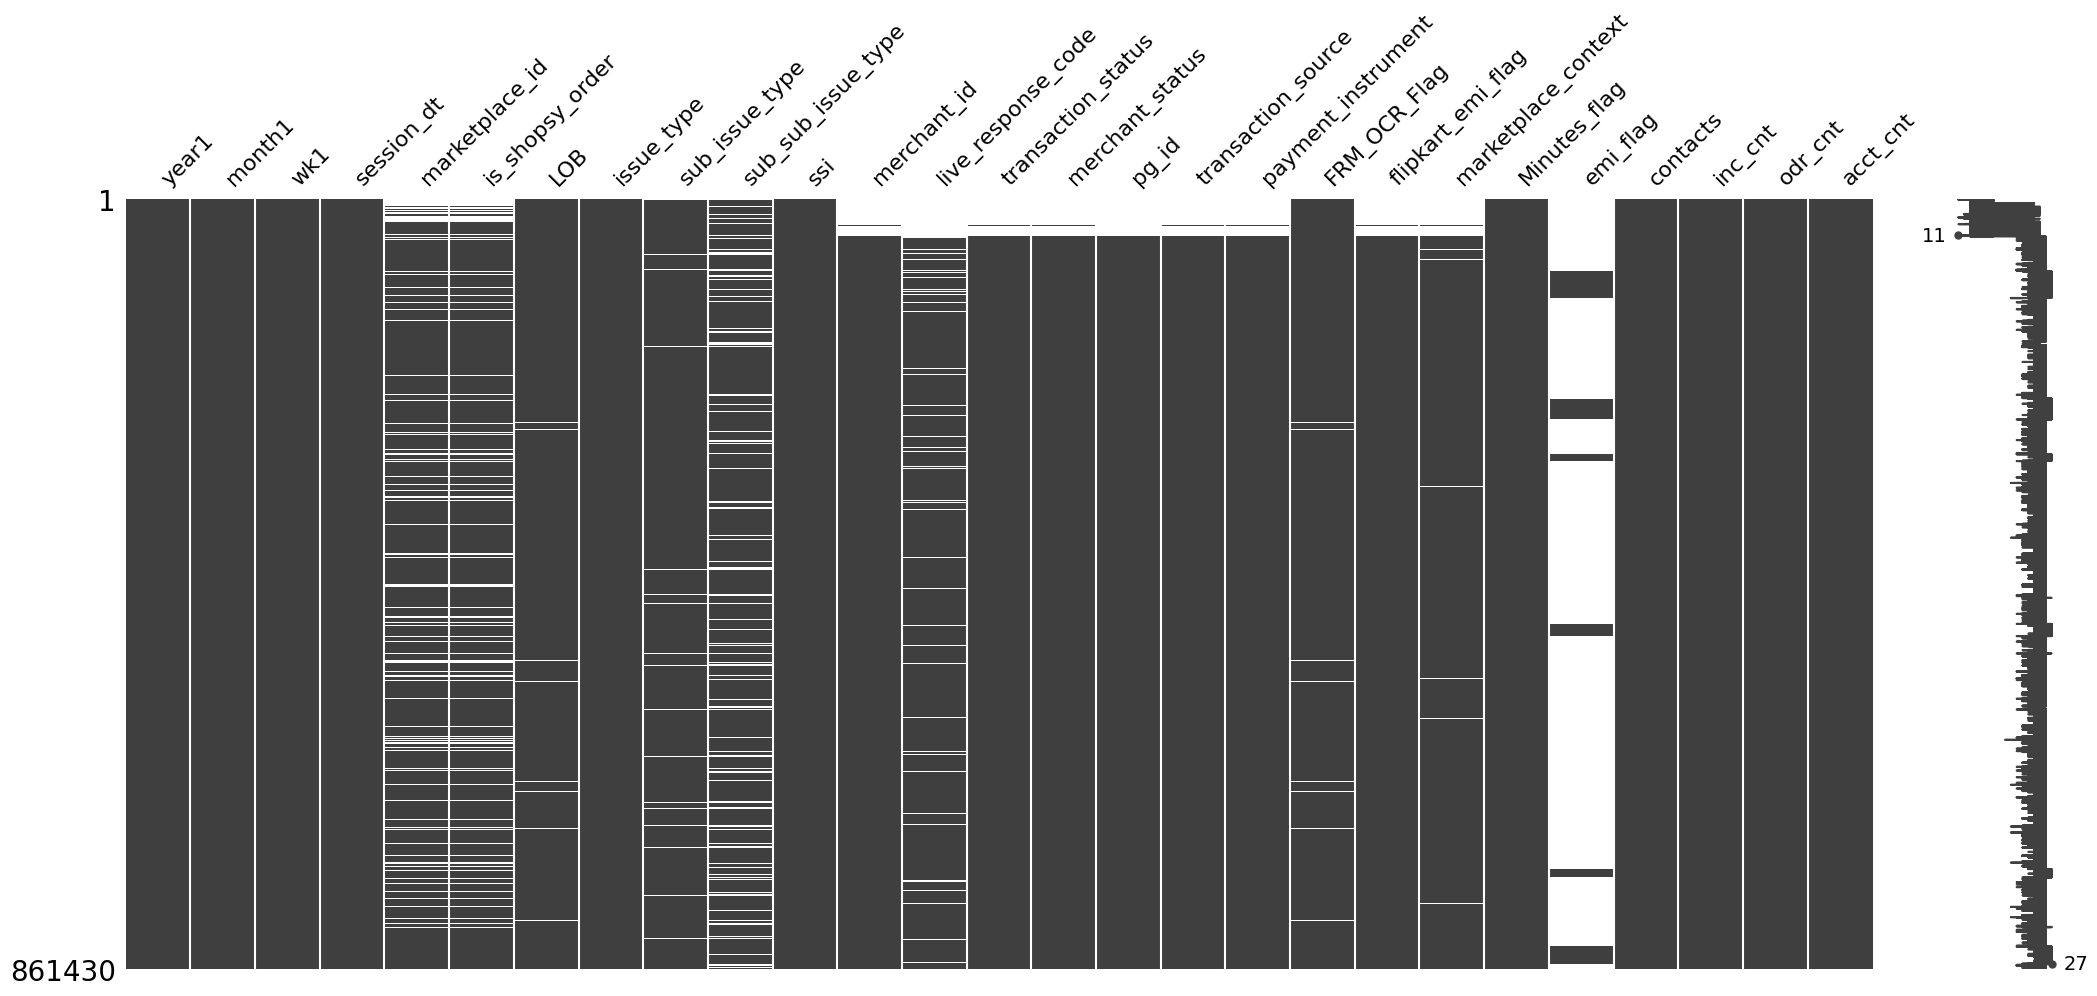

In [9]:
import missingno as msno
import matplotlib.pyplot as plt
msno.matrix(df)

In [10]:
from sklearn.preprocessing import LabelEncoder
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(-1)
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('unknown')

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print(df)
                            

        year1  month1  wk1 session_dt  marketplace_id  is_shopsy_order  LOB  \
0        2026       1    2 2026-01-10               4                2   23   
1        2026       1    4 2026-01-19               4                2   11   
2        2026       1    4 2026-01-19               4                2   23   
3        2026       1    2 2026-01-09               4                2   47   
4        2026       1    4 2026-01-24               4                2   45   
...       ...     ...  ...        ...             ...              ...  ...   
861425   2026       1    1 2026-01-02               1                0   23   
861426   2026       1    3 2026-01-11               1                0   25   
861427   2026       1    4 2026-01-19               1                0   33   
861428   2026       1    3 2026-01-16               1                0   23   
861429   2026       1    3 2026-01-12               4                2   35   

        issue_type  sub_issue_type  sub_sub_issue_t

In [11]:
print(df.dtypes)

year1                           int64
month1                          int64
wk1                             int64
session_dt             datetime64[ns]
marketplace_id                  int64
is_shopsy_order                 int64
LOB                             int64
issue_type                      int64
sub_issue_type                  int64
sub_sub_issue_type              int64
ssi                             int64
merchant_id                     int64
live_response_code              int64
transaction_status              int64
merchant_status                 int64
pg_id                           int64
transaction_source              int64
payment_instrument              int64
FRM_OCR_Flag                    int64
flipkart_emi_flag               int64
marketplace_context             int64
Minutes_flag                    int64
emi_flag                        int64
contacts                        int64
inc_cnt                         int64
odr_cnt                         int64
acct_cnt    

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
df['session_dt'] = pd.to_numeric(df['session_dt'])
df_clean = df[df['contacts'] > 30000].copy()
##exclude_cols = ['contacts', 'year1','month1','wk1','session_dt']
X= df_clean[['issue_type', 'sub_issue_type', 'sub_sub_issue_type']]
y= df_clean['contacts']

Linear Regression R2: 0.0000
Linear Regression MAE: 2597.49


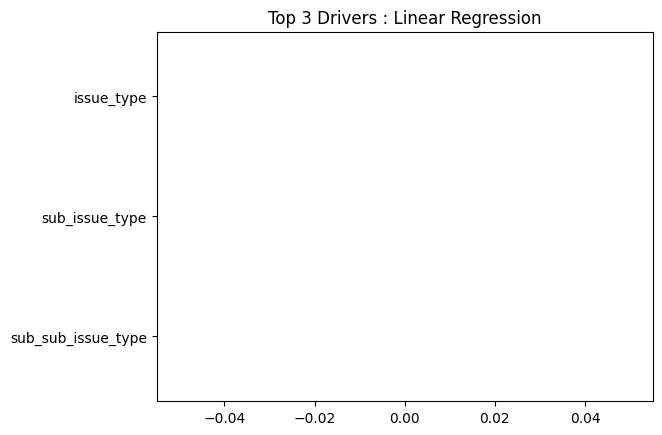

In [17]:
lr_model = LinearRegression().fit(X,y)
preds = lr_model.predict(X)
print(f"Linear Regression R2: {r2_score(y,preds):.4f}")
print(f"Linear Regression MAE: {mean_absolute_error(y,preds):.2f}")

drivers = pd.DataFrame({'Features':X.columns, 'Weight':np.abs(lr_model.coef_)})
top5 = drivers.sort_values(by='Weight', ascending=False).head(5)

plt.barh(top5['Features'], top5['Weight'], color='royalblue')
plt.title("Top 3 Drivers : Linear Regression")
plt.gca().invert_yaxis()
plt.show()



Random Forest R2: -0.0001
Random Forest MAE: 2594.12


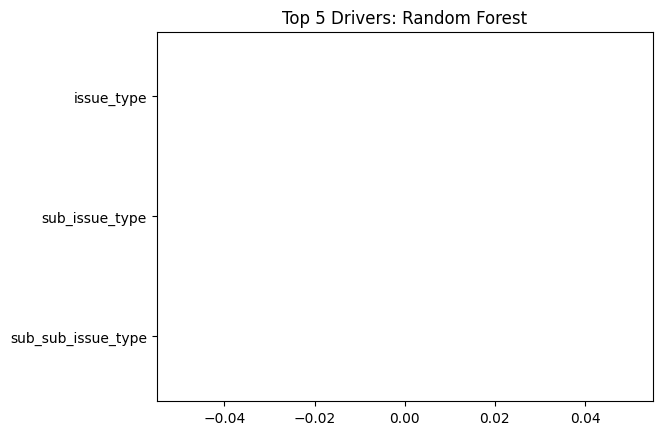

In [15]:
#randomForest 
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators = 100, random_state=42).fit(X,y)
preds = rf_model.predict(X)

print(f"Random Forest R2: {r2_score(y,preds):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y, preds):.2f}")

drivers = pd.DataFrame({'Feature': X.columns, 'Importance':rf_model.feature_importances_})
top_5 = drivers.sort_values(by='Importance', ascending=False).head(5)

plt.barh(top_5['Feature'],top_5['Importance'],color='darkgreen')
plt.title("Top 5 Drivers: Random Forest")
plt.gca().invert_yaxis()
plt.show()

XGBoost R2: 0.0000
XGBoost MAE: 2597.49


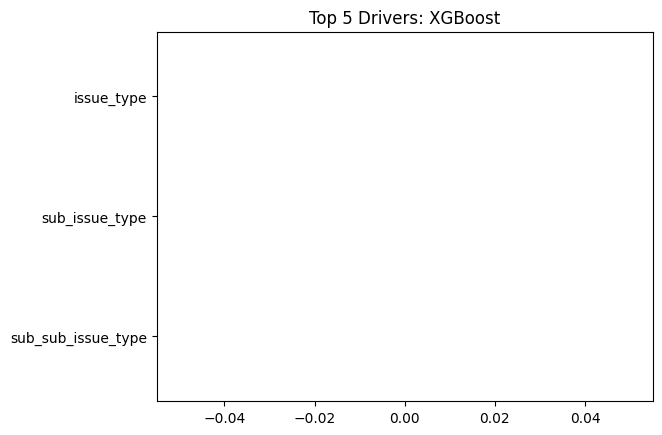

In [16]:
#XGBoost 
from xgboost import XGBRegressor

xgb_model = XGBRegressor().fit(X,y)
preds = xgb_model.predict(X)


print(f"XGBoost R2: {r2_score(y, preds):.4f}")
print(f"XGBoost MAE: {mean_absolute_error(y, preds):.2f}")

drivers = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_model.feature_importances_})
top_5 = drivers.sort_values(by='Importance', ascending=False).head(5)

plt.barh(top_5['Feature'],top_5['Importance'], color = 'orange')
plt.title("Top 5 Drivers: XGBoost")
plt.gca().invert_yaxis()
plt.show()

Lasso R2: 0.9973


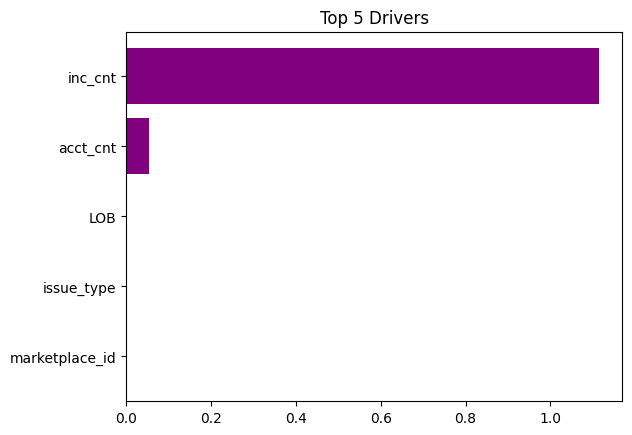

In [64]:
#Lasso Regression (The Feature Selector)

from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1).fit(X,y)
preds = lasso_model.predict(X)

print(f"Lasso R2: {r2_score(y, preds):.4f}")

drivers = pd.DataFrame({'Feature': X.columns, 'Weight': np.abs(lasso_model.coef_)})
top_5 = drivers.sort_values(by='Weight', ascending=False).head(5)
plt.barh(top_5['Feature'], top_5['Weight'], color= 'purple')
plt.title("Top 5 Drivers")
plt.gca().invert_yaxis()
plt.show()

Decision Tree R2:0.9994


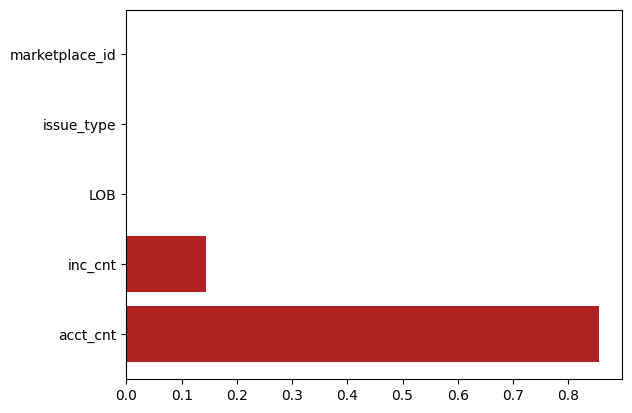

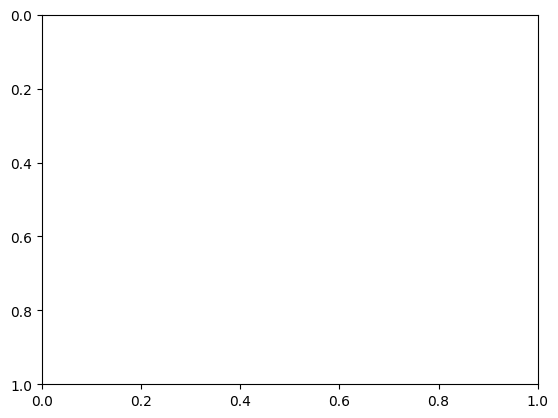

In [69]:
##Decision Tree (The Explainable Model)
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5).fit(X,y)
preds= dt_model.predict(X)

print(f"Decision Tree R2:{r2_score(y, preds):.4f}")
drivers = pd.DataFrame({'Feature':X.columns, 'Importance':dt_model.feature_importances_})
top_5 = drivers.sort_values(by='Importance', ascending=False).head(5)

plt.barh(top_5['Feature'], top_5['Importance'], color = 'firebrick')
plt.show("Top 5 Drivers: Decision Tree")
plt.gca().invert_yaxis()
plt.show()


In [72]:
weekly_summary = df.groupby('wk1').agg({
    'contacts': 'sum',
    'odr_cnt': 'sum'
}).reset_index()
print(weekly_summary)

   wk1  contacts  odr_cnt
0    1    725534   456344
1    2   1803997  1162503
2    3   1790577  1121506
3    4   1948455  1243183
4    5   1414929   903538


In [78]:
shopsy_analysis = df.groupby('is_shopsy_order').agg({
    'contacts': 'sum',
    'odr_cnt': 'sum'
}).reset_index()

shopsy_analysis['contact_rate'] =  shopsy_analysis['contacts']/shopsy_analysis['odr_cnt'] *100 
print(shopsy_analysis)

   is_shopsy_order  contacts  odr_cnt  contact_rate
0                0   5048062  4590007    109.979397
1                1    330480   297067    111.247631
2                2   2304950        0           inf


In [80]:
status_health= df.groupby('transaction_status')['inc_cnt'].sum().sort_values(ascending=False).reset_index()
print(status_health)


   transaction_status  inc_cnt
0                   3  5132610
1                   4  1806200
2                   0   239810
3                   2      592
4                   1       28


In [84]:
latest_month =df['month1'].max()
monthly_df = df[df['month1'] == latest_month]
deep_dive = monthly_df.groupby(['marketplace_id' , 'LOB'])['contacts'].sum().reset_index()
print(deep_dive.head(20))

    marketplace_id  LOB  contacts
0                0    0        18
1                0    1         1
2                0    3      6275
3                0    4      1804
4                0    5    561794
5                0    6      2646
6                0    7      3754
7                0    8       121
8                0    9     25367
9                0   10      4036
10               0   11     85458
11               0   12     53830
12               0   13         7
13               0   14      6220
14               0   15         7
15               0   16     58234
16               0   17    407902
17               0   18        75
18               0   20     85491
19               0   21        13


Senior Linear Regression R2: 0.0000


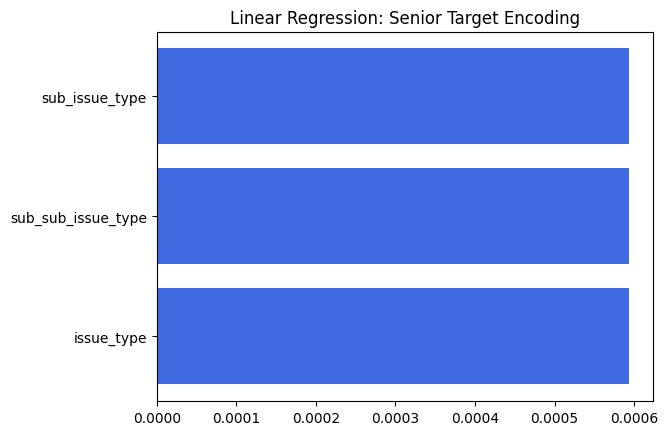

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# --- 1. Senior Prep (Target Encoding) ---
df_ml = df_clean.copy()
cols_to_encode = ['issue_type', 'sub_issue_type', 'sub_sub_issue_type']

for col in cols_to_encode:
    # Replace ID with its Mean Contact volume
    mean_val = df_ml.groupby(col)['contacts'].transform('mean')
    df_ml[col] = np.log1p(mean_val) # Log the feature to match scale

X = df_ml[cols_to_encode]
y_log = np.log1p(df_ml['contacts'])

# --- 2. Model & Inference ---
lr_model = LinearRegression().fit(X, y_log)
preds_log = lr_model.predict(X)
r2 = r2_score(y_log, preds_log)

print(f"Senior Linear Regression R2: {r2:.4f}")

# --- 3. Drivers & Plot ---
drivers = pd.DataFrame({'Feature': X.columns, 'Weight': np.abs(lr_model.coef_)})
top5 = drivers.sort_values(by='Weight', ascending=False).head(5)

plt.barh(top5['Feature'], top5['Weight'], color='royalblue')
plt.title("Linear Regression: Senior Target Encoding")
plt.gca().invert_yaxis()
plt.show()

In [22]:
# 1. Create the results table
drivers_numbers = pd.DataFrame({
    'Feature': X.columns,
    'Raw_Weight': lr_model.coef_,
    'Absolute_Weight': np.abs(lr_model.coef_)
})

# 2. Print the technical stats
print(f"--- Model Performance ---")
print(f"R-Squared Score: {lr_model.score(X, y_log):.6f}")
print(f"Model Intercept (Baseline Log-Volume): {lr_model.intercept_:.6f}")

print("\n--- Numerical Drivers ---")
print(drivers_numbers.sort_values(by='Absolute_Weight', ascending=False))

--- Model Performance ---
R-Squared Score: 0.000000
Model Intercept (Baseline Log-Volume): 10.414731

--- Numerical Drivers ---
              Feature  Raw_Weight  Absolute_Weight
1      sub_issue_type    0.000594         0.000594
2  sub_sub_issue_type    0.000594         0.000594
0          issue_type    0.000594         0.000594


In [28]:
# 1. Check if the features actually have different values
print("--- Feature Uniqueness ---")
print(X.nunique()) 

# 2. Check the spread of your target
print("\n--- Target Variance ---")
print(f"Standard Deviation of Contacts: {df_clean['contacts'].std():.2f}")
print(f"Mean of Contacts: {df_clean['contacts'].mean():.2f}")

# 3. Check for Nulls
print("\n--- Missing Values ---")
print(X.isnull().sum())

--- Feature Uniqueness ---
issue_type         1
sub_issue_type     1
odr_cnt            1
is_shopsy_order    1
LOB                1
dtype: int64

--- Target Variance ---
Standard Deviation of Contacts: 3191.07
Mean of Contacts: 34110.09

--- Missing Values ---
issue_type         0
sub_issue_type     0
odr_cnt            0
is_shopsy_order    0
LOB                0
dtype: int64
